# LLM Posterior — ARC-AGI Explorer
Load tasks, inspect prompts, run LOO on a single task, and visualize results.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path().resolve()))

from dotenv import load_dotenv
load_dotenv()

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec

from src.data_loader import load_task, load_all_tasks
from src.grid_utils import grid_to_str, grids_match, grid_diff, ARC_COLORS
from src.hypothesis_agent import build_prompt, generate_hypothesis
from src.leave_one_out import run_task_loo
from src.evaluate import evaluate_task

TASK_DIR = pathlib.Path("data/ARC-AGI/data/training")
print(f"Tasks available: {len(list(TASK_DIR.glob('*.json')))}")

Tasks available: 400


## 1. Pick a task and inspect it

In [19]:
# Change TASK_ID to any stem from data/ARC-AGI/data/training/
TASK_ID = "d22278a0"

task = load_task(TASK_DIR / f"{TASK_ID}.json")
print(f"Task: {task.task_id}")
print(f"Train pairs: {len(task.train)}")
print(f"Test pairs:  {len(task.test)}")
print(f"\nTrain[0] input shape:  {len(task.train[0].input)} x {len(task.train[0].input[0])}")
print(f"Train[0] output shape: {len(task.train[0].output)} x {len(task.train[0].output[0])}")

Task: d22278a0
Train pairs: 4
Test pairs:  1

Train[0] input shape:  10 x 10
Train[0] output shape: 10 x 10


## 2. Visualize all train pairs

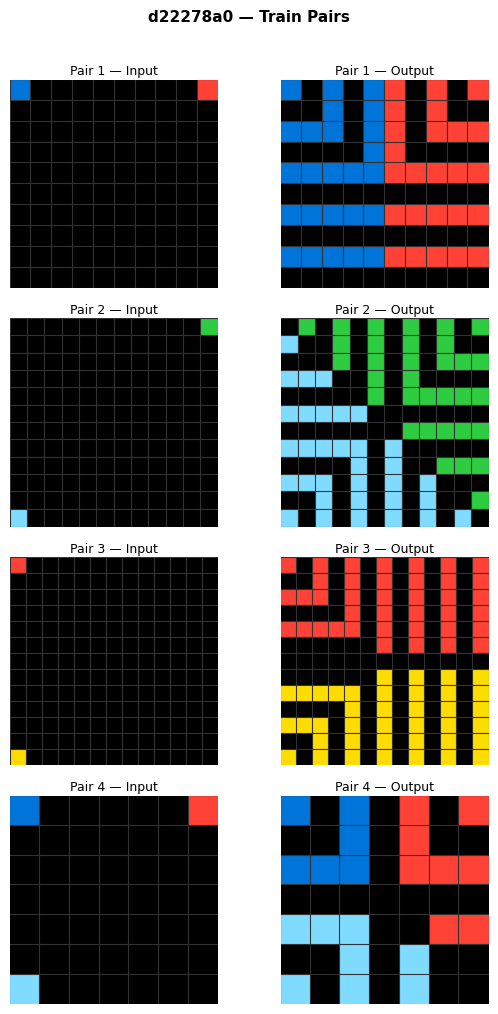

In [20]:
def draw_grid(ax, grid, title=""):
    rows = len(grid)
    cols = max(len(r) for r in grid) if grid else 1
    for r, row in enumerate(grid):
        for c, val in enumerate(row):
            color = ARC_COLORS.get(val, "#000000")
            rect = mpatches.FancyBboxPatch(
                (c, rows - r - 1), 1, 1,
                boxstyle="square,pad=0.02",
                facecolor=color, edgecolor="#333333", linewidth=0.8,
            )
            ax.add_patch(rect)
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title, fontsize=9, pad=4)


def visualize_pairs(pairs, title=""):
    n = len(pairs)
    fig, axes = plt.subplots(n, 2, figsize=(6, n * 2.5))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.01)
    for i, (ax_row, pair) in enumerate(zip(axes, pairs)):
        draw_grid(ax_row[0], pair.input,  f"Pair {i+1} — Input")
        draw_grid(ax_row[1], pair.output, f"Pair {i+1} — Output")
    plt.tight_layout()
    plt.show()


visualize_pairs(task.train, title=f"{task.task_id} — Train Pairs")

## 3. Visualize test pair(s)

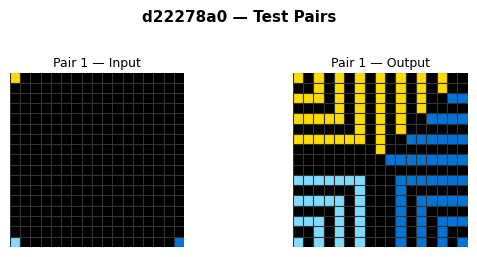

In [21]:
visualize_pairs(task.test, title=f"{task.task_id} — Test Pairs")

## 4. Inspect the LLM prompt (dry run)

In [22]:
# LOO iteration 0: hold out train[0], use train[1:] as demos
demo_pairs = task.train[1:]
test_input  = task.train[0].input

prompt = build_prompt(demo_pairs, test_input)
print(prompt)

## Demonstration pairs:
Pair 1:
Input:
0 0 0 0 0 0 0 0 0 0 0 3
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0
8 0 0 0 0 0 0 0 0 0 0 0

Output:
0 3 0 3 0 3 0 3 0 3 0 3
8 0 0 3 0 3 0 3 0 3 0 0
0 0 0 3 0 3 0 3 0 3 3 3
8 8 8 0 0 3 0 3 0 0 0 0
0 0 0 0 0 3 0 3 3 3 3 3
8 8 8 8 8 0 0 0 0 0 0 0
0 0 0 0 0 0 0 3 3 3 3 3
8 8 8 8 8 0 8 0 0 0 0 0
0 0 0 0 8 0 8 0 0 3 3 3
8 8 8 0 8 0 8 0 8 0 0 0
0 0 8 0 8 0 8 0 8 0 0 3
8 0 8 0 8 0 8 0 8 0 8 0

Pair 2:
Input:
2 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
0 0 0 0 0 0 0 0 0 0 0 0 0
4 0 0 0 0 0 0 0 0 0 0 0 0

Output:
2 0 2 0 2 0 2

## 5. Run LOO on this task  *(requires OPENAI_API_KEY)*

In [ ]:
from langchain_openai import ChatOpenAI
from src.hypothesis_agent import build_chain

MODEL = "gpt-4.1-mini"   # change to gpt-4o for better results
llm = ChatOpenAI(model=MODEL, temperature=0)
chain = build_chain(llm)

# Jupyter supports top-level await
task_result = await run_task_loo(task, chain=chain, model=MODEL, compress_analysts=False)

print(f"LOO accuracy:  {task_result.loo_accuracy:.2f}  ({sum(r.exact_match for r in task_result.loo_results)}/{len(task_result.loo_results)} exact)")
print(f"Test accuracy: {task_result.test_accuracy:.2f}  ({sum(r.exact_match for r in task_result.test_results)}/{len(task_result.test_results)} exact)")

[d22278a0] LOO+test done (4 loo, 1 test)
[d22278a0] refinement done (4 refined)
[d22278a0] synthesis done (master_train=100%)
[d22278a0] generator done (1 test outputs)
LOO accuracy:  0.00  (0/4 exact)
Test accuracy: 0.00  (0/1 exact)


## 6. Visualize LOO predictions vs ground truth

=== LOO predictions ===


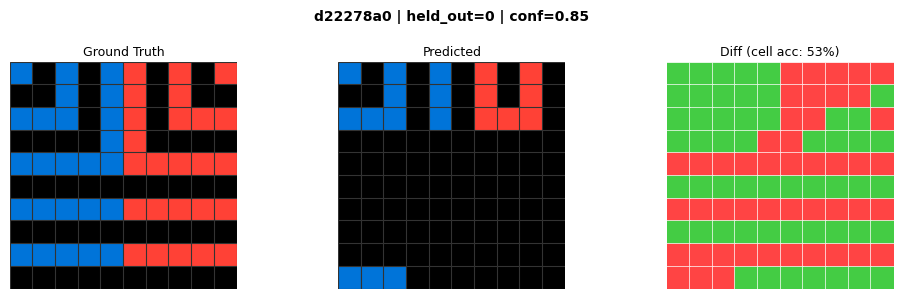

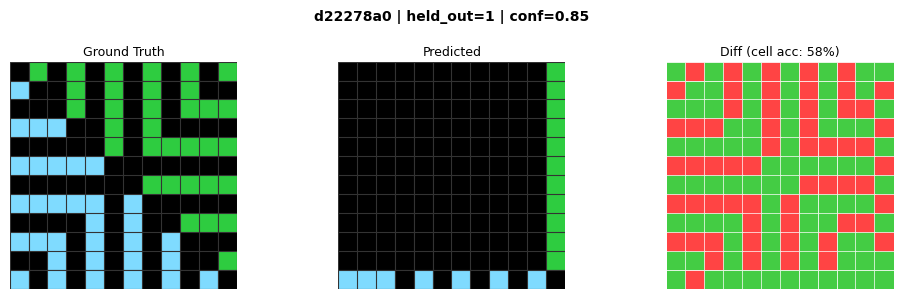

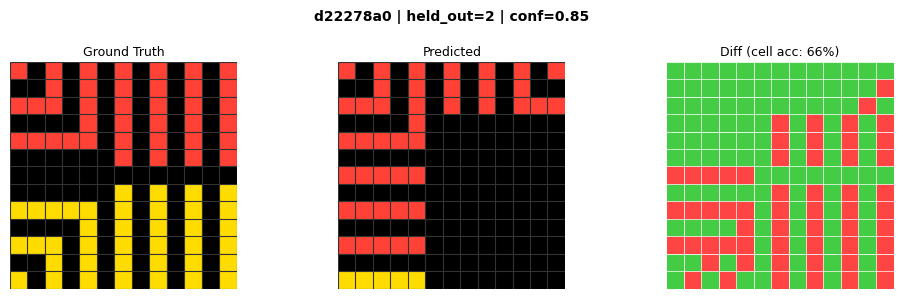

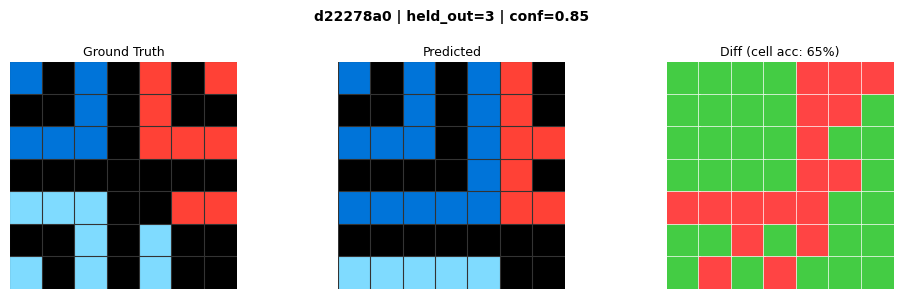

In [28]:
def visualize_prediction(result, title=""):
    """Show predicted vs actual side by side, with diff overlay."""
    predicted = result.predicted_output
    actual    = result.actual_output
    diff      = grid_diff(predicted, actual)
    mismatches = set(diff["mismatches"])

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    draw_grid(axes[0], actual,    "Ground Truth")
    draw_grid(axes[1], predicted, "Predicted")

    # Diff panel: green = match, red = mismatch, grey = size issue
    ax = axes[2]
    if diff["size_match"] and predicted:
        rows = len(predicted)
        cols = len(predicted[0])
        for r in range(rows):
            for c in range(cols):
                color = "#ff4444" if (r, c) in mismatches else "#44cc44"
                rect = mpatches.FancyBboxPatch(
                    (c, rows - r - 1), 1, 1,
                    boxstyle="square,pad=0.02",
                    facecolor=color, edgecolor="white", linewidth=0.5,
                )
                ax.add_patch(rect)
        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)
    else:
        ax.text(0.5, 0.5, "Size\nMismatch", ha="center", va="center",
                fontsize=12, color="red", transform=ax.transAxes)

    match_str = "EXACT MATCH" if result.exact_match else f"cell acc: {diff['cell_accuracy']:.0%}"
    ax.set_title(f"Diff ({match_str})", fontsize=9, pad=4)
    ax.set_aspect("equal")
    ax.axis("off")

    label = f"held_out={result.held_out_index}" if not result.is_test else "test"
    fig.suptitle(f"{title} | {label} | conf={result.confidence:.2f}",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()


print("=== LOO predictions ===")
for r in task_result.loo_results:
    visualize_prediction(r, title=task.task_id)

=== Test predictions ===


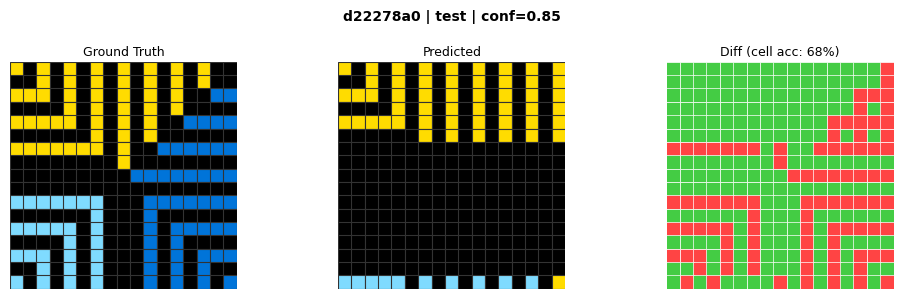

In [25]:
print("=== Test predictions ===")
for r in task_result.test_results:
    visualize_prediction(r, title=task.task_id)

## 6b. Refined predictions (self-correction pass)

Refined 4/4 LOO predictions
LOO accuracy:          0.00
Refined LOO accuracy:  1.00


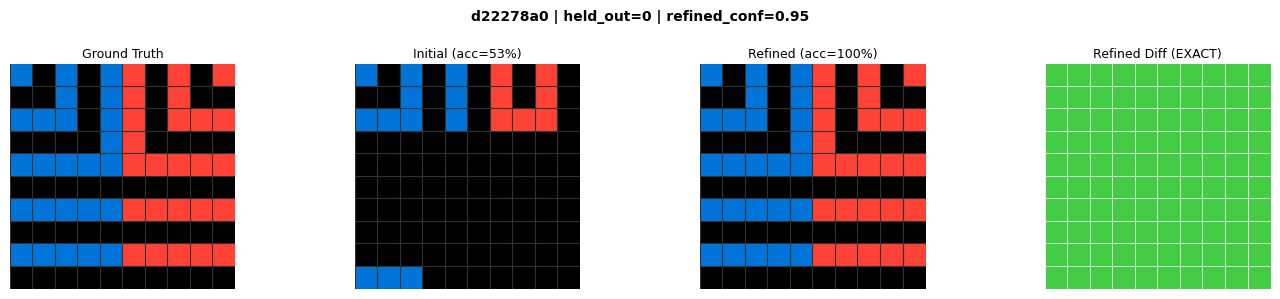

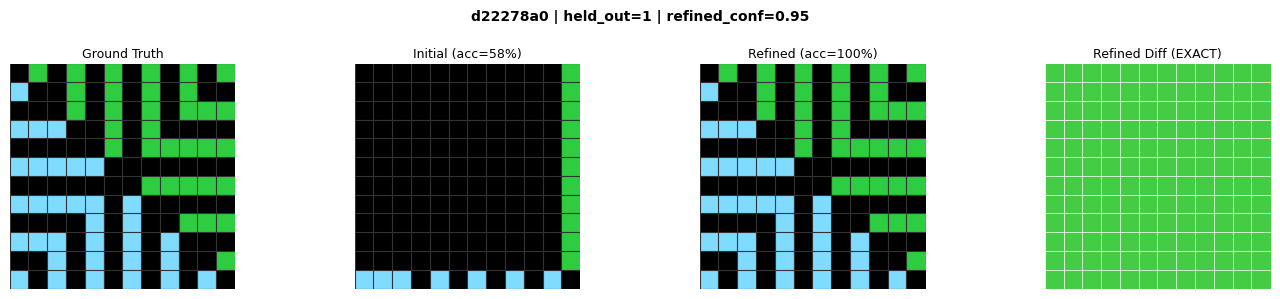

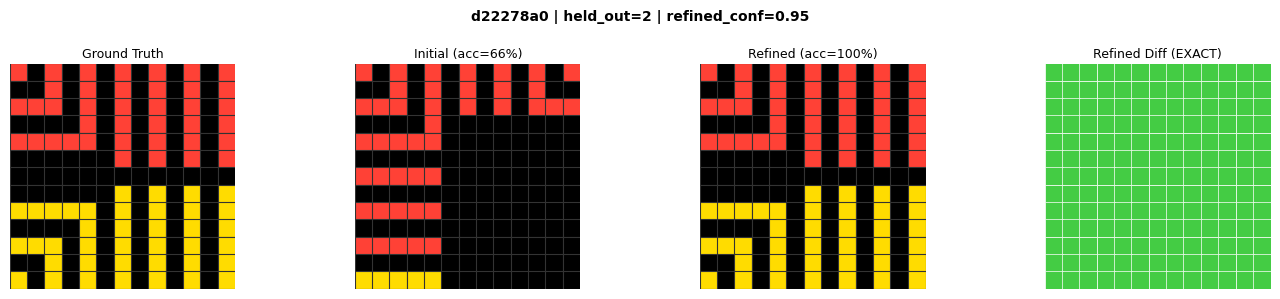

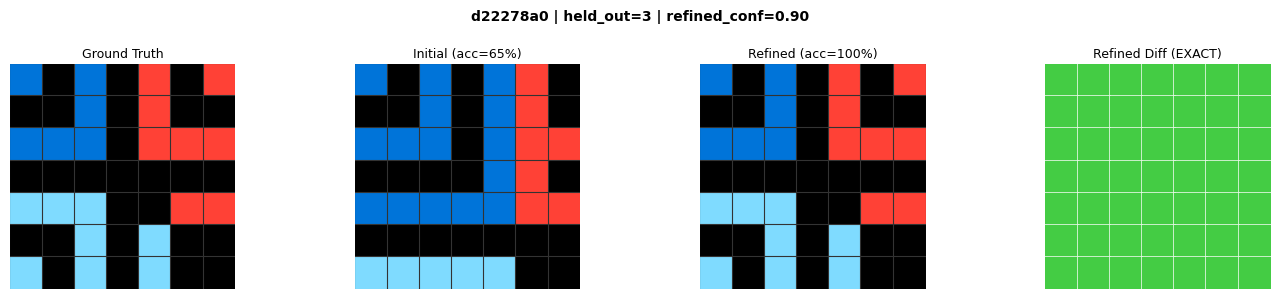

In [26]:
def visualize_refined(result, title=""):
    """4-panel: ground truth / initial predicted / refined predicted / refined diff."""
    if result.refined_predicted_output is None:
        return
    predicted  = result.predicted_output
    refined    = result.refined_predicted_output
    actual     = result.actual_output
    diff       = grid_diff(refined, actual)
    mismatches = set(diff["mismatches"])

    fig, axes = plt.subplots(1, 4, figsize=(14, 3))
    draw_grid(axes[0], actual,     "Ground Truth")
    draw_grid(axes[1], predicted,  f"Initial (acc={result.cell_accuracy:.0%})")
    draw_grid(axes[2], refined,    f"Refined (acc={result.refined_cell_accuracy:.0%})")

    ax = axes[3]
    if diff["size_match"] and refined:
        rows, cols = len(refined), len(refined[0])
        for r in range(rows):
            for c in range(cols):
                color = "#ff4444" if (r, c) in mismatches else "#44cc44"
                rect = mpatches.FancyBboxPatch(
                    (c, rows - r - 1), 1, 1,
                    boxstyle="square,pad=0.02",
                    facecolor=color, edgecolor="white", linewidth=0.5,
                )
                ax.add_patch(rect)
        ax.set_xlim(0, cols)
        ax.set_ylim(0, rows)
    else:
        ax.text(0.5, 0.5, "Size\nMismatch", ha="center", va="center",
                fontsize=12, color="red", transform=ax.transAxes)

    match_str = "EXACT" if result.refined_exact_match else f"{diff['cell_accuracy']:.0%}"
    ax.set_title(f"Refined Diff ({match_str})", fontsize=9, pad=4)
    ax.set_aspect("equal")
    ax.axis("off")

    label = f"held_out={result.held_out_index}"
    fig.suptitle(f"{title} | {label} | refined_conf={result.refined_confidence:.2f}",
                 fontsize=10, fontweight="bold")
    plt.tight_layout()
    plt.show()


refined_count = sum(1 for r in task_result.loo_results if r.refined_predicted_output is not None)
print(f"Refined {refined_count}/{len(task_result.loo_results)} LOO predictions")
print(f"LOO accuracy:          {task_result.loo_accuracy:.2f}")
print(f"Refined LOO accuracy:  {task_result.refined_loo_accuracy:.2f}")

for r in task_result.loo_results:
    visualize_refined(r, title=task.task_id)

## 6c. Master synthesis (unified hypothesis)

In [ ]:
from src.grid_utils import grids_match, grid_diff

mr = task_result.master_result
gen_results = task_result.generator_results

if mr and mr.unified_hypothesis:
    print(f"Unified hypothesis:\n  {mr.unified_hypothesis}\n")
    print(f"Analyst gaps:        {mr.analyst_gaps}")
    print(f"Key transformations: {mr.key_transformations}")
    print(f"Reasoning:           {mr.reasoning}\n")

if gen_results:
    print(f"\nGenerator predicted {len(gen_results)} test output(s):")
    for j, gen_r in enumerate(gen_results):
        actual = task.test[j].output
        test_r = task_result.test_results[j]
        gen_grid = gen_r.predicted_output
        initial_grid = test_r.predicted_output
        refined_grid = test_r.refined_predicted_output

        initial_acc = test_r.cell_accuracy
        gen_acc = grid_diff(gen_grid, actual)["cell_accuracy"] if gen_grid else 0.0
        gen_match = grids_match(gen_grid, actual) if gen_grid else False

        print(f"\nTest {j}:")
        print(f"  Initial:   exact_match={test_r.exact_match}, cell_accuracy={initial_acc:.1%}")
        if refined_grid is not None:
            refined_acc = test_r.refined_cell_accuracy or 0.0
            print(f"  Refined:   exact_match={test_r.refined_exact_match}, cell_accuracy={refined_acc:.1%}")
        print(f"  Generator: exact_match={gen_match}, cell_accuracy={gen_acc:.1%}")
        if gen_r.step_by_step_trace:
            print(f"  Trace: {gen_r.step_by_step_trace[:200]}")

        fig, axes = plt.subplots(1, 5, figsize=(12.5, 2.5))
        draw_grid(axes[0], task.test[j].input, title="Input")
        draw_grid(axes[1], initial_grid, title=f"Initial\n{initial_acc:.0%}")
        if refined_grid is not None:
            draw_grid(axes[2], refined_grid, title=f"Refined\n{test_r.refined_cell_accuracy:.0%}")
        else:
            axes[2].set_title("Refined\n(n/a)", fontsize=9)
            axes[2].axis("off")
        if gen_grid:
            draw_grid(axes[3], gen_grid, title=f"Generator\n{gen_acc:.0%}")
        else:
            axes[3].set_title("Generator\n(failed)", fontsize=9)
            axes[3].axis("off")
        draw_grid(axes[4], actual, title="Ground truth")
        plt.tight_layout()
        plt.show()
else:
    print("No generator results available.")

## 6.d Peeking into the input for the hyopthesis synthesizer

In [42]:
from IPython.display import display, HTML
import html

def pretty_display_base_input(data: dict) -> None:
    blocks = []
    for key, value in data.items():
        escaped = html.escape(value if isinstance(value, str) else repr(value))
        blocks.append(f"""
        <div style="
            border:1px solid #ccc;
            border-radius:10px;
            padding:12px;
            margin:12px 0;
            background:#000000;
        ">
            <div style="font-weight:bold; font-size:16px; margin-bottom:8px;">{html.escape(key)}</div>
            <pre style="
                white-space:pre-wrap;
                word-break:break-word;
                margin:0;
                font-family:monospace;
                font-size:13px;
                line-height:1.4;
            ">{escaped}</pre>
        </div>
        """)
    display(HTML("".join(blocks)))

pretty_display_base_input(base_input)

## 7. Per-task metrics

In [11]:
from src.evaluate import evaluate_task
metrics = evaluate_task(task_result)

for k, v in metrics.items():
    print(f"  {k}: {v:.3f}" if isinstance(v, float) else f"  {k}: {v}")

  task_id: 007bbfb7
  loo_exact_match_rate: 0.000
  test_exact_match_rate: 0.000
  mean_cell_accuracy: 0.759
  num_loo_pairs: 5
  num_test_pairs: 1


## 8. Inspect a specific LOO hypothesis

In [12]:
# Change index to inspect different LOO results
for i in range(4):
    
    r = task_result.loo_results[i]

    print(f"Held out: train[{r.held_out_index}]")
    print(f"Exact match: {r.exact_match}  |  Cell accuracy: {r.cell_accuracy:.2%}  |  Confidence: {r.confidence:.2f}")
    print(f"\nHypothesis:\n  {r.hypothesis}")
    print(f"\nReasoning:\n  {r.reasoning}")
    print(f"\nRefined Hypothesis:\n  {r.refined_hypothesis}")
    print(f"\nRefined Reasoning:\n  {r.refined_reasoning}")

Held out: train[0]
Exact match: False  |  Cell accuracy: 77.78%  |  Confidence: 0.90

Hypothesis:
  The output is a 9x9 grid formed by placing the 3x3 input grid in a 3x3 block pattern, where each block is the input grid itself, but with zeros replaced by zeros and non-zero values preserved in their positions. The pattern is arranged so that the input grid is tiled in the top-left, top-middle, top-right, middle-left, middle-middle, middle-right, bottom-left, bottom-middle, and bottom-right blocks, with zeros filling the rest of the 9x9 grid. Essentially, the 3x3 input is repeated in a 3x3 grid to form the 9x9 output, with zeros outside the input blocks.

Reasoning:
  In all demonstration pairs, the 3x3 input grid is expanded into a 9x9 output grid by tiling the input grid in a 3x3 arrangement. Each 3x3 block in the output corresponds to the input grid, placed in the respective position. The zeros in the input remain zeros in the output, and the non-zero values are preserved in their re

In [13]:
refined    = r.refined_predicted_output
actual     = r.actual_output
diff       = grid_diff(refined, actual)
print(diff)

def _describe_errors(mismatches: list[tuple[int, int]], rows: int, cols: int) -> str:
    """Summarise mismatch positions as a human-readable spatial description."""
    if not mismatches:
        return "no errors"

    def _range_str(indices: list[int]) -> str:
        return str(indices[0]) if len(indices) == 1 else f"{indices[0]}-{indices[-1]}"

    error_rows = sorted({r for r, _ in mismatches})
    error_cols = sorted({c for _, c in mismatches})
    return (
        f"{len(mismatches)} cell(s) incorrect; "
        f"errors in rows {_range_str(error_rows)}, "
        f"cols {_range_str(error_cols)} "
        f"(grid is {rows}\u00d7{cols})"
    )

rows = len(refined)
cols = len(refined[0]) if refined else 0
cell_acc_pct = round(diff["cell_accuracy"] * 100, 1)
error_desc = _describe_errors(diff["mismatches"], rows, cols)
print(error_desc)

{'size_match': True, 'cell_accuracy': 1.0, 'mismatches': []}
no errors


## 9. Batch evaluation — 20 tasks

Run the full pipeline on 20 randomly sampled training tasks to see where the pipeline
breaks down across the three failure modes:

- **Cat 1** — Generator nails it (exact match on all test outputs)
- **Cat 2** — Master found the right rule (100% train acc) but generator fumbled execution
- **Cat 3** — Master failed to find the rule (train acc < 100%)

Large Cat 2 → the ViT's job. Large Cat 3 → need better hypothesis generation.

In [9]:
import random
import asyncio

N_BATCH = 20
TASK_TIMEOUT = 180  # seconds per task; kills stuck network calls
N_CONCURRENT = 3   # tasks in flight at once (avoids OS socket pressure on Windows)

random.seed(42)
all_paths = sorted(TASK_DIR.glob("*.json"))
sample_paths = random.sample(all_paths, N_BATCH)
batch_tasks = [load_task(p) for p in sample_paths]

print(f"Sampled {N_BATCH} tasks (≤{N_CONCURRENT} concurrent, {TASK_TIMEOUT}s timeout each):")
for t in batch_tasks:
    print(f"  {t.task_id}  ({len(t.train)} train, {len(t.test)} test)")

sem = asyncio.Semaphore(N_CONCURRENT)

async def run_one(t):
    async with sem:
        return await asyncio.wait_for(run_task_loo(t, model=MODEL), timeout=TASK_TIMEOUT)

print("\nRunning full pipeline (LOO → refine → master → generator)...")
batch_results = await asyncio.gather(*[run_one(t) for t in batch_tasks], return_exceptions=True)

ok_pairs = [(t, r) for t, r in zip(batch_tasks, batch_results)
            if not isinstance(r, Exception)]
errors   = [(t.task_id, r) for t, r in zip(batch_tasks, batch_results)
            if isinstance(r, Exception)]
if errors:
    for tid, e in errors:
        print(f"  FAILED {tid}: {type(e).__name__}: {str(e)[:80]}")
print(f"Done: {len(ok_pairs)}/{N_BATCH} tasks succeeded.")

Sampled 20 tasks (≤3 concurrent, 180s timeout each):
  d22278a0  (4 train, 1 test)
  28e73c20  (5 train, 1 test)
  0a938d79  (4 train, 1 test)
  ed36ccf7  (4 train, 1 test)
  623ea044  (3 train, 1 test)
  54d82841  (3 train, 1 test)
  4be741c5  (3 train, 1 test)
  3428a4f5  (4 train, 2 test)
  ec883f72  (4 train, 1 test)
  25ff71a9  (4 train, 2 test)
  dae9d2b5  (5 train, 2 test)
  b527c5c6  (4 train, 1 test)
  22eb0ac0  (3 train, 1 test)
  c1d99e64  (3 train, 1 test)
  8f2ea7aa  (3 train, 1 test)
  0dfd9992  (3 train, 1 test)
  0d3d703e  (4 train, 1 test)
  239be575  (6 train, 2 test)
  4938f0c2  (3 train, 1 test)
  50cb2852  (3 train, 1 test)

Running full pipeline (LOO → refine → master → generator)...
[0a938d79] LOO+test done (4 loo, 1 test)
[d22278a0] LOO+test done (4 loo, 1 test)
[28e73c20] LOO+test done (5 loo, 1 test)
[d22278a0] refinement done (4 refined)
[28e73c20] refinement done (5 refined)
[0a938d79] refinement done (4 refined)
[d22278a0] synthesis done (master_train=100%)

In [17]:
for task, item in ok_pairs:
    if item.master_result:
        print(item.master_result)

agreements='All analysts agree that the transformation depends on identifying two distinct nonzero colors in the input grid, each located near or at corners or edges of the grid, typically one near the top row and one near the bottom row. They agree the output pattern is constructed based on these two colors.' disagreements="The analysts disagree on the exact positions of these two colors: some say top-right and bottom-left corners, others say top-left and bottom-left, or top-left and top-right corners. This disagreement arises because each analyst saw different input pairs with different color placements, leading them to overfit to specific corner positions rather than generalizing that the two colors are located at opposite edges or corners of the input grid. Therefore, the exact corner or edge positions of the two colors are not fixed but depend on the input's actual placement of these colors." key_insight='The key insight is that the two distinct nonzero colors are always located a

In [ ]:
from collections import Counter

CAT_LABELS = {1: "Cat 1: Generator nails it", 2: "Cat 2: Generator missed"}
CAT_COLORS = {1: "#4CAF50", 2: "#F44336"}


def classify(task, tr):
    """Return (category, gen_cell_acc)."""
    gen = tr.generator_results
    if gen and task.test:
        gen_exact = all(
            grids_match(g.predicted_output, pair.output)
            for g, pair in zip(gen, task.test)
            if g.predicted_output
        )
        gen_accs = [
            grid_diff(g.predicted_output, pair.output)["cell_accuracy"]
            for g, pair in zip(gen, task.test) if g.predicted_output
        ]
        gen_cell_acc = sum(gen_accs) / len(gen_accs) if gen_accs else 0.0
    else:
        gen_exact    = False
        gen_cell_acc = 0.0
    return (1 if gen_exact else 2), gen_cell_acc


rows = [
    {
        "task_id":      tr.task_id,
        "cat":          classify(t, tr)[0],
        "gen_cell_acc": classify(t, tr)[1],
        "loo_acc":      tr.loo_accuracy,
        "ref_loo_acc":  tr.refined_loo_accuracy or 0.0,
    }
    for t, tr in ok_pairs
]

# Per-task table
print(f"\n{'task_id':<13} {'gen_cell':>9} {'ref_loo':>8} {'cat':>4}")
print("-" * 38)
for r in sorted(rows, key=lambda x: x["cat"]):
    print(f"{r['task_id']:<13} {r['gen_cell_acc']:>9.1%} {r['ref_loo_acc']:>8.1%} {r['cat']:>4}")

# Distribution summary
cat_counts = Counter(r["cat"] for r in rows)
total = len(rows)
print(f"\n--- Distribution ({total} tasks) ---")
for c in [1, 2]:
    n = cat_counts.get(c, 0)
    print(f"  {CAT_LABELS[c]}: {n} ({n/total:.0%})")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Bar chart
ax = axes[0]
cats = [1, 2]
counts = [cat_counts.get(c, 0) for c in cats]
bars = ax.bar(
    [CAT_LABELS[c] for c in cats], counts,
    color=[CAT_COLORS[c] for c in cats], edgecolor="black", linewidth=0.8,
)
for bar, n in zip(bars, counts):
    ax.text(
        bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
        f"{n}\n({n/total:.0%})", ha="center", va="bottom", fontsize=9,
    )
ax.set_title(f"Pipeline breakdown — {total} tasks", fontweight="bold")
ax.set_ylabel("# tasks")
ax.set_ylim(0, max(counts) + 2.5)

# Scatter: ref_loo_acc vs gen_cell_acc
ax2 = axes[1]
for r in rows:
    ax2.scatter(
        r["ref_loo_acc"], r["gen_cell_acc"],
        c=CAT_COLORS[r["cat"]], s=80, edgecolors="black", linewidths=0.6, zorder=3,
    )
    ax2.annotate(
        r["task_id"][:6], (r["ref_loo_acc"], r["gen_cell_acc"]),
        fontsize=6, alpha=0.7, textcoords="offset points", xytext=(4, 2),
    )
ax2.axvline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
ax2.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, alpha=0.5)
for c in [1, 2]:
    ax2.scatter([], [], c=CAT_COLORS[c], s=60, edgecolors="black",
                linewidths=0.5, label=f"Cat {c}")
ax2.set_xlabel("Refined LOO accuracy (analyst quality)")
ax2.set_ylabel("Generator test cell accuracy")
ax2.set_title("Analyst quality vs generator quality", fontweight="bold")
ax2.set_xlim(-0.05, 1.08)
ax2.set_ylim(-0.05, 1.08)
ax2.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

## 9b. Deep-dive into a single batch task

In [ ]:
# Change to any task_id from ok_pairs to inspect it
INSPECT_ID = ok_pairs[0][0].task_id

inspect_task, inspect_tr = next((t, r) for t, r in ok_pairs if t.task_id == INSPECT_ID)
mr   = inspect_tr.master_result
gen_results = inspect_tr.generator_results

print(f"=== {inspect_task.task_id} | cat={rows[[r['task_id'] for r in rows].index(INSPECT_ID)]['cat']} ===\n")
print(f"LOO accuracy:          {inspect_tr.loo_accuracy:.1%}")
print(f"Refined LOO accuracy:  {inspect_tr.refined_loo_accuracy:.1%}")

if mr and mr.unified_hypothesis:
    print(f"\nUnified hypothesis:\n  {mr.unified_hypothesis}")
    print(f"Analyst gaps:        {mr.analyst_gaps}")
    print(f"Key transformations: {mr.key_transformations}")
    print(f"Reasoning:           {mr.reasoning}")
else:
    print("\n(No master result)")

if gen_results:
    print(f"\nGenerator predicted {len(gen_results)} test output(s):")
    for j, gen_r in enumerate(gen_results):
        actual       = inspect_task.test[j].output
        test_r       = inspect_tr.test_results[j]
        gen_grid     = gen_r.predicted_output
        initial_grid = test_r.predicted_output
        refined_grid = test_r.refined_predicted_output

        initial_acc = test_r.cell_accuracy
        gen_acc     = grid_diff(gen_grid, actual)["cell_accuracy"] if gen_grid else 0.0
        gen_match   = grids_match(gen_grid, actual) if gen_grid else False

        print(f"\nTest {j}:")
        print(f"  Initial:   exact={test_r.exact_match}, acc={initial_acc:.1%}")
        if refined_grid is not None:
            print(f"  Refined:   exact={test_r.refined_exact_match}, acc={test_r.refined_cell_accuracy:.1%}")
        print(f"  Generator: exact={gen_match}, acc={gen_acc:.1%}")
        if gen_r.step_by_step_trace:
            print(f"  Trace: {gen_r.step_by_step_trace[:300]}")

        fig, axes = plt.subplots(1, 5, figsize=(12.5, 2.5))
        draw_grid(axes[0], inspect_task.test[j].input, title="Input")
        draw_grid(axes[1], initial_grid,  title=f"Initial\n{initial_acc:.0%}")
        if refined_grid is not None:
            draw_grid(axes[2], refined_grid, title=f"Refined\n{test_r.refined_cell_accuracy:.0%}")
        else:
            axes[2].set_title("Refined\n(n/a)", fontsize=9); axes[2].axis("off")
        if gen_grid:
            draw_grid(axes[3], gen_grid, title=f"Generator\n{gen_acc:.0%}")
        else:
            axes[3].set_title("Generator\n(failed)", fontsize=9); axes[3].axis("off")
        draw_grid(axes[4], actual, title="Ground truth")
        fig.suptitle(f"{inspect_task.task_id} — test[{j}]", fontsize=10, fontweight="bold")
        plt.tight_layout()
        plt.show()
else:
    print("\n(No generator results)")